# Сравнение методов решения транспортной задачи в цепочке поставок


## 1. Импорты и настройка

In [ ]:
import sys, os, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, NamedTuple

from scipy.optimize import linprog
from scipy.sparse import lil_matrix
import networkx as nx

**Сравниваемые методы:**

1. Северо-западный угол (жадная эвристика)
2. Метод Фогеля (жадная с регретом)
3. MODI
4. Симплекс HiGHS-DS (LP)
5. Метод внутренней точки HiGHS-IPM (LP)
6. Min-cost flow
7. Genetic Algorithm (метаэвристика)
8. Simulated Annealing (метаэвристика)

## 2. EDA

https://www.kaggle.com/datasets/suraj9727/supply-chain-optimization-for-a-fmcg-company


In [ ]:
raw = pd.read_csv('/content/FMCG_data.csv')

raw.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071


In [ ]:
raw.shape

(25000, 24)

In [ ]:
raw['zone'].value_counts()

,count
zone,
North,10278
West,7931
South,6362
East,429


In [ ]:
raw['WH_capacity_size'].value_counts()

,count
WH_capacity_size,
Large,10169
Mid,10020
Small,4811


In [ ]:
raw['product_wg_ton'].describe()

,product_wg_ton
count,25000.000000
mean,22102.632920
std,11607.755077
min,2065.000000
25%,13059.000000
50%,22101.000000
75%,30103.000000
max,55151.000000


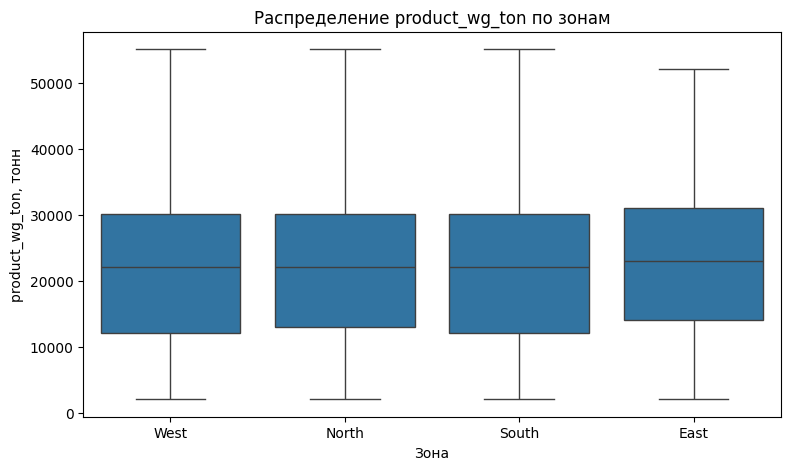

In [ ]:
fig = plt.figure(figsize=(9, 5))
sns.boxplot(data=raw, x="zone", y="product_wg_ton")
plt.xlabel("Зона")
plt.ylabel("product_wg_ton, тонн")
plt.title("Распределение product_wg_ton по зонам")
plt.show()

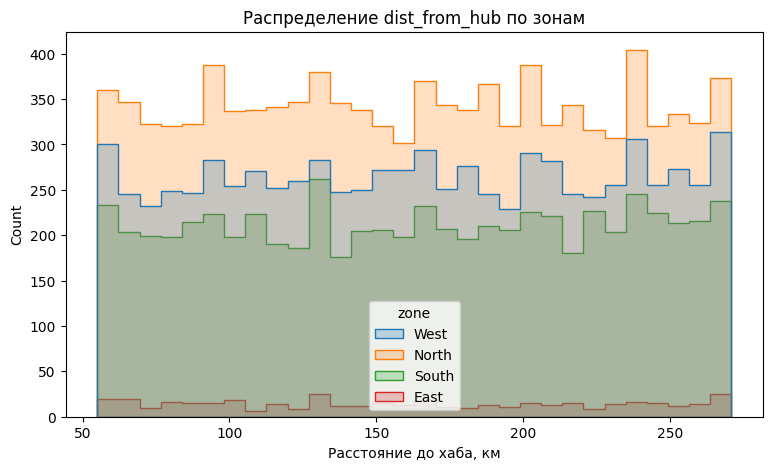

In [ ]:
fig = plt.figure(figsize=(9, 5))
sns.histplot(raw, x='dist_from_hub', hue='zone', bins=30, element='step')
plt.title('Распределение dist_from_hub по зонам')
plt.xlabel('Расстояние до хаба, км')
plt.show()

## 3. Постановка транспортной задачи на FMCG-данных

In [ ]:
from dataclasses import dataclass, field

@dataclass
class TransportProblem:
    supply: np.ndarray
    demand: np.ndarray
    cost: np.ndarray
    sources: list[str] = field(default_factory=list)
    sinks: list[str] = field(default_factory=list)

    def __post_init__(self) -> None:
        self.supply = np.asarray(self.supply, dtype=float)
        self.demand = np.asarray(self.demand, dtype=float)
        self.cost = np.asarray(self.cost, dtype=float)
        m, n = self.cost.shape
        if self.supply.shape != (m,):
            raise ValueError(f"supply shape {self.supply.shape} != ({m},)")
        if self.demand.shape != (n,):
            raise ValueError(f"demand shape {self.demand.shape} != ({n},)")
        if not self.sources:
            self.sources = [f"S{i}" for i in range(m)]
        if not self.sinks:
            self.sinks = [f"D{j}" for j in range(n)]

    @property
    def m(self) -> int:
        return self.cost.shape[0]

    @property
    def n(self) -> int:
        return self.cost.shape[1]

    @property
    def is_balanced(self) -> bool:
        return np.isclose(self.supply.sum(), self.demand.sum())

    def balanced(self) -> "TransportProblem":
        s, d = self.supply.sum(), self.demand.sum()
        if np.isclose(s, d):
            return self
        cost = self.cost.copy()
        if s > d:
            extra = np.zeros((self.m, 1))
            cost = np.hstack([cost, extra])
            demand = np.append(self.demand, s - d)
            sinks = self.sinks + ["DUMMY_SINK"]
            return TransportProblem(self.supply.copy(), demand, cost, self.sources.copy(), sinks)
        else:
            extra = np.zeros((1, self.n))
            cost = np.vstack([cost, extra])
            supply = np.append(self.supply, d - s)
            sources = self.sources + ["DUMMY_SOURCE"]
            return TransportProblem(supply, self.demand.copy(), cost, sources, self.sinks.copy())

    def feasible(self, x: np.ndarray, tol: float = 1e-6) -> bool:
        x = np.asarray(x)
        if x.shape != self.cost.shape or (x < -tol).any():
            return False
        if (x.sum(axis=1) > self.supply + tol).any():
            return False
        if (x.sum(axis=0) < self.demand - tol).any():
            return False
        return True

    def total_cost(self, x: np.ndarray) -> float:
        return float((self.cost * x).sum())

In [ ]:
cross_zone_penalty = 2.2
transport_issue_mult = 0.15
breakdown_mult = 0.05
flood_risk_mult = 0.40
capacity_slack = 1.20

In [ ]:
def _capacity_factor(size: str) -> float:
    return {"Small": 0.6, "Mid": 1.0, "Large": 1.6}.get(size, 1.0)

In [ ]:
def build_problem(
    df: pd.DataFrame,
    sample_warehouses_per_zone: int | None = None,
    random_state: int = 42,
) -> TransportProblem:

    df = df.copy()
    df["demand"] = df["product_wg_ton"].astype(float)

    if sample_warehouses_per_zone is not None:
        parts = []
        for _, grp in df.groupby("zone"):
            n_take = min(len(grp), sample_warehouses_per_zone)
            parts.append(grp.sample(n=n_take, random_state=random_state))
        df = pd.concat(parts).reset_index(drop=True)

    zones = sorted(df["zone"].unique())
    zone_idx = {z: i for i, z in enumerate(zones)}

    m = len(zones)
    n = len(df)

    base_dist = df["dist_from_hub"].to_numpy()  # (n,)
    issue = df["transport_issue_l1y"].to_numpy()
    breakdown = df["wh_breakdown_l3m"].to_numpy()
    flood_risk = (df["flood_impacted"] * (1 - df["flood_proof"])).to_numpy()
    wh_zone_idx = df["zone"].map(zone_idx).to_numpy()

    cost = np.zeros((m, n))
    for i in range(m):
        same = (wh_zone_idx == i).astype(float)
        zone_mult = same + (1 - same) * cross_zone_penalty
        mult = (
            1.0
            + transport_issue_mult * issue
            + breakdown_mult * breakdown
            + flood_risk_mult * flood_risk
        )
        cost[i] = base_dist * zone_mult * mult

    cap_factor = df["WH_capacity_size"].map(_capacity_factor).to_numpy()
    supply = np.zeros(m)
    for i, z in enumerate(zones):
        mask = wh_zone_idx == i
        supply[i] = (df["demand"].to_numpy()[mask] * cap_factor[mask]).sum() * capacity_slack

    if supply.sum() < df["demand"].sum():
        deficit = df["demand"].sum() - supply.sum()
        supply += deficit / m * 1.05

    sources = [f"HUB_{z}" for z in zones]
    sinks = df["Ware_house_ID"].tolist()

    return TransportProblem(
        supply=supply,
        demand=df["demand"].to_numpy(),
        cost=cost,
        sources=sources,
        sinks=sinks,
    )

In [ ]:
problem_full = build_problem(raw)
print(f'Полная задача: m={problem_full.m} (зоны), n={problem_full.n} (склады), nvar={problem_full.m*problem_full.n:,}')
print(f'Σ supply = {problem_full.supply.sum():,.0f}')
print(f'Σ demand = {problem_full.demand.sum():,.0f}')
print(f'Источники: {problem_full.sources}')

problem = build_problem(raw, sample_warehouses_per_zone=50, random_state=42)
print(f'\nСемпл: m={problem.m}, n={problem.n}, nvar={problem.m*problem.n}')
print(f'Σ supply = {problem.supply.sum():,.0f}, Σ demand = {problem.demand.sum():,.0f}')

Полная задача: m=4 (зоны), n=25000 (склады), nvar=100,000
Σ supply = 774,319,399
Σ demand = 552,565,823
Источники: ['HUB_East', 'HUB_North', 'HUB_South', 'HUB_West']

Семпл: m=4, n=200, nvar=800
Σ supply = 6,091,960, Σ demand = 4,591,261


In [ ]:
out = ROOT
out.mkdir(exist_ok=True)
pd.DataFrame({'source': problem.sources, 'supply': problem.supply}).to_csv(out / 'supply.csv', index=False)
pd.DataFrame({'sink': problem.sinks, 'demand': problem.demand}).to_csv(out / 'demand.csv', index=False)
pd.DataFrame(problem.cost, index=problem.sources, columns=problem.sinks).to_csv(out / 'cost_matrix.csv')

## 4. Инициализация методов

In [ ]:
@dataclass
class SolveResult:
    x: np.ndarray              # план перевозок
    cost: float                # значение целевой
    wall_time_s: float         # время счёта
    iterations: Optional[int] = None
    status: str = "ok"
    details: dict | None = None

### Северо-западный угол (жадная эвристика)

In [ ]:
def _strip_dummy(x: np.ndarray, problem_balanced: TransportProblem,
                 orig: TransportProblem) -> np.ndarray:
    m, n = orig.m, orig.n
    return x[:m, :n]

In [ ]:
def _northwest_corner(supply: np.ndarray, demand: np.ndarray) -> np.ndarray:
    s = supply.astype(float).copy()
    d = demand.astype(float).copy()
    m, n = len(s), len(d)
    x = np.zeros((m, n))
    i = j = 0
    while i < m and j < n:
        q = min(s[i], d[j])
        x[i, j] = q
        s[i] -= q
        d[j] -= q
        if s[i] <= 1e-9 and i < m - 1:
            i += 1
        elif d[j] <= 1e-9 and j < n - 1:
            j += 1
        else:
            if s[i] <= 1e-9:
                i += 1
            else:
                j += 1
    return x


def solve_nw_corner(problem: TransportProblem) -> SolveResult:
    t0 = time.perf_counter()
    p = problem.balanced()
    x = _northwest_corner(p.supply, p.demand)
    dt = time.perf_counter() - t0
    x = _strip_dummy(x, p, problem)
    return SolveResult(x=x, cost=problem.total_cost(x), wall_time_s=dt)

### Метод Фогеля (жадная с регретом)

In [ ]:
def _vogel(cost: np.ndarray, supply: np.ndarray, demand: np.ndarray) -> np.ndarray:
    s = supply.astype(float).copy()
    d = demand.astype(float).copy()
    c = cost.astype(float).copy()
    m, n = c.shape
    x = np.zeros((m, n))
    active_rows = np.ones(m, dtype=bool)
    active_cols = np.ones(n, dtype=bool)

    def _two_smallest(arr: np.ndarray) -> float:
        if len(arr) < 2:
            return 0.0
        srt = np.partition(arr, 1)[:2]
        return float(srt[1] - srt[0])

    while active_rows.any() and active_cols.any():
        row_pen = np.full(m, -np.inf)
        col_pen = np.full(n, -np.inf)
        for i in np.where(active_rows)[0]:
            row = c[i, active_cols]
            if len(row) >= 2:
                row_pen[i] = _two_smallest(row)
            elif len(row) == 1:
                row_pen[i] = float(row[0])
        for j in np.where(active_cols)[0]:
            col = c[active_rows, j]
            if len(col) >= 2:
                col_pen[j] = _two_smallest(col)
            elif len(col) == 1:
                col_pen[j] = float(col[0])

        max_row = row_pen.max() if row_pen.size else -np.inf
        max_col = col_pen.max() if col_pen.size else -np.inf
        if max_row >= max_col:
            i = int(np.argmax(row_pen))
            cols = np.where(active_cols)[0]
            j = int(cols[np.argmin(c[i, cols])])
        else:
            j = int(np.argmax(col_pen))
            rows = np.where(active_rows)[0]
            i = int(rows[np.argmin(c[rows, j])])

        q = min(s[i], d[j])
        x[i, j] = q
        s[i] -= q
        d[j] -= q
        if s[i] <= 1e-9:
            active_rows[i] = False
        if d[j] <= 1e-9:
            active_cols[j] = False
    return x


def solve_vogel(problem: TransportProblem) -> SolveResult:
    t0 = time.perf_counter()
    p = problem.balanced()
    x = _vogel(p.cost, p.supply, p.demand)
    dt = time.perf_counter() - t0
    x = _strip_dummy(x, p, problem)
    return SolveResult(x=x, cost=problem.total_cost(x), wall_time_s=dt)

### MODI

In [ ]:
def _find_cycle(basis: np.ndarray, ei: int, ej: int):
    m, n = basis.shape
    B = basis.copy()
    B[ei, ej] = True
    path = [(ei, ej)]

    def dfs(direction: str) -> bool:
        cur_i, cur_j = path[-1]
        if direction == "row":
            for j in range(n):
                if j == cur_j:
                    continue
                if B[cur_i, j]:
                    if (cur_i, j) == (ei, ej) and len(path) >= 3:
                        return True
                    if (cur_i, j) in path:
                        continue
                    path.append((cur_i, j))
                    if dfs("col"):
                        return True
                    path.pop()
        else:
            for i in range(m):
                if i == cur_i:
                    continue
                if B[i, cur_j]:
                    if (i, cur_j) == (ei, ej) and len(path) >= 3:
                        return True
                    if (i, cur_j) in path:
                        continue
                    path.append((i, cur_j))
                    if dfs("row"):
                        return True
                    path.pop()
        return False

    if dfs("row") or dfs("col"):
        return path
    return None

In [ ]:
def _modi_improve(cost: np.ndarray, x: np.ndarray, max_iter: int = 10_000) -> tuple[np.ndarray, int]:
    x = x.astype(float).copy()
    m, n = cost.shape
    iters = 0
    eps_basis = 1e-9
    basis = x > eps_basis
    needed = m + n - 1
    if basis.sum() < needed:
        order = np.argsort(cost.ravel())
        eps = 1e-8
        for flat in order:
            i, j = divmod(flat, n)
            if not basis[i, j]:
                x[i, j] = eps
                basis[i, j] = True
                if basis.sum() >= needed:
                    break

    for it in range(max_iter):
        iters = it + 1
        u = np.full(m, np.nan)
        v = np.full(n, np.nan)
        u[0] = 0.0
        changed = True
        while changed:
            changed = False
            for i in range(m):
                for j in range(n):
                    if basis[i, j]:
                        if not np.isnan(u[i]) and np.isnan(v[j]):
                            v[j] = cost[i, j] - u[i]
                            changed = True
                        elif np.isnan(u[i]) and not np.isnan(v[j]):
                            u[i] = cost[i, j] - v[j]
                            changed = True
        u = np.where(np.isnan(u), 0.0, u)
        v = np.where(np.isnan(v), 0.0, v)

        reduced = cost - u[:, None] - v[None, :]
        reduced[basis] = 0.0
        min_red = reduced.min()
        if min_red >= -1e-9:
            breakdown_mult

        ei, ej = np.unravel_index(np.argmin(reduced), reduced.shape)

        cycle = _find_cycle(basis, ei, ej)
        if cycle is None:
            break
        plus = cycle[0::2]
        minus = cycle[1::2]
        theta = min(x[i, j] for (i, j) in minus)
        for (i, j) in plus:
            x[i, j] += theta
        for (i, j) in minus:
            x[i, j] -= theta
        basis = x > eps_basis
        if basis.sum() < needed:
            for (i, j) in plus + minus:
                if not basis[i, j] and basis.sum() < needed:
                    x[i, j] = max(x[i, j], 1e-10)
                    basis[i, j] = True

    x[x < 1e-7] = 0.0
    return x, iters

def solve_modi(problem: TransportProblem, init: str = "vogel",
               max_iter: int = 5000) -> SolveResult:
    t0 = time.perf_counter()
    p = problem.balanced()
    if init == "vogel":
        x = _vogel(p.cost, p.supply, p.demand)
    else:
        x = _northwest_corner(p.supply, p.demand)
    x, iters = _modi_improve(p.cost, x, max_iter=max_iter)
    dt = time.perf_counter() - t0
    x = _strip_dummy(x, p, problem)
    return SolveResult(x=x, cost=problem.total_cost(x), wall_time_s=dt, iterations=iters,details={"init": init})

### Симплекс HiGHS-DS (LP)

In [ ]:
def _build_lp(problem: TransportProblem):
    m, n = problem.m, problem.n
    nvar = m * n
    c = problem.cost.ravel()
    A = lil_matrix((m + n, nvar))
    b = np.zeros(m + n)
    for i in range(m):
        for j in range(n):
            A[i, i * n + j] = 1.0
        b[i] = problem.supply[i]
    for j in range(n):
        for i in range(m):
            A[m + j, i * n + j] = -1.0
        b[m + j] = -problem.demand[j]
    return c, A.tocsr(), b


def _solve_with_method(problem: TransportProblem, method: str) -> SolveResult:
    c, A, b = _build_lp(problem)
    t0 = time.perf_counter()
    res = linprog(c, A_ub=A, b_ub=b, bounds=(0, None), method=method)
    dt = time.perf_counter() - t0
    if not res.success:
        return SolveResult(
            x=np.zeros((problem.m, problem.n)),
            cost=float("inf"),
            wall_time_s=dt,
            status=f"fail: {res.message}",
        )
    x = res.x.reshape(problem.m, problem.n)
    return SolveResult(
        x=x,
        cost=float(res.fun),
        wall_time_s=dt,
        iterations=getattr(res, "nit", None),
        status="ok",
        details={"method": method, "message": res.message},
    )

In [ ]:
def solve_simplex(problem: TransportProblem) -> SolveResult:
    return _solve_with_method(problem, method="highs-ds")

### Метод внутренней точки HiGHS-IPM (LP)

In [ ]:
def solve_interior_point(problem: TransportProblem) -> SolveResult:
    return _solve_with_method(problem, method="highs-ipm")

### Min-cost flow

In [ ]:
COST_SCALE = 1000
SUPPLY_SCALE = 1


def solve_mcf(problem: TransportProblem) -> SolveResult:
    m, n = problem.m, problem.n
    t0 = time.perf_counter()

    s = np.round(problem.supply * SUPPLY_SCALE).astype(int)
    d = np.round(problem.demand * SUPPLY_SCALE).astype(int)

    DUMMY_NODE = m + n

    node_map: dict[str, int] = {}
    for i in range(m):
        node_map[f"src_{i}"] = i
    for j in range(n):
        node_map[f"snk_{j}"] = m + j
    node_map["dummy"] = DUMMY_NODE

    id_to_node: dict[int, str] = {v: k for k, v in node_map.items()}

    assert all(f"src_{i}" in node_map for i in range(m)), "node_map: missing source nodes"
    assert all(f"snk_{j}" in node_map for j in range(n)), "node_map: missing sink nodes"

    G = nx.DiGraph()

    for i in range(m):
        G.add_node(node_map[f"src_{i}"], demand=-int(s[i]))
    for j in range(n):
        G.add_node(node_map[f"snk_{j}"], demand=int(d[j]))

    total = int(s.sum()) - int(d.sum())
    if total > 0:
        G.add_node(DUMMY_NODE, demand=total)
        for i in range(m):
            G.add_edge(node_map[f"src_{i}"], DUMMY_NODE, weight=0, capacity=int(s[i]))
    elif total < 0:
        G.add_node(DUMMY_NODE, demand=total)
        for j in range(n):
            G.add_edge(DUMMY_NODE, node_map[f"snk_{j}"], weight=10 ** 9, capacity=int(d[j]))

    for i in range(m):
        for j in range(n):
            G.add_edge(node_map[f"src_{i}"], node_map[f"snk_{j}"], weight=int(round(problem.cost[i, j] * COST_SCALE)), capacity=int(s[i]))

    flow_cost, flow_dict = nx.network_simplex(G)
    dt = time.perf_counter() - t0

    x = np.zeros((m, n))
    for i in range(m):
        src_id = node_map[f"src_{i}"]
        for j in range(n):
            snk_id = node_map[f"snk_{j}"]
            x[i, j] = flow_dict.get(src_id, {}).get(snk_id, 0) / SUPPLY_SCALE

    return SolveResult(
        x=x,
        cost=problem.total_cost(x),
        wall_time_s=dt,
        status="ok",
        details={
            "algorithm": "network_simplex",
            "scaled_cost": flow_cost / COST_SCALE,
            "node_map_size": len(node_map),
        },
    )

### Genetic Algorithm (метаэвристика)

In [ ]:
def _random_feasible(problem: TransportProblem, rng: np.random.Generator) -> np.ndarray:
    p = problem.balanced()
    m, n = p.m, p.n
    perm_r = rng.permutation(m)
    perm_c = rng.permutation(n)
    x_p = _northwest_corner(p.supply[perm_r], p.demand[perm_c])
    inv_r = np.argsort(perm_r)
    inv_c = np.argsort(perm_c)
    x = x_p[inv_r][:, inv_c]
    return x[: problem.m, : problem.n]

In [ ]:
def _swap_move(x: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    m, n = x.shape
    nonzero = np.argwhere(x > 1e-9)
    if len(nonzero) < 1:
        return x
    a = nonzero[rng.integers(len(nonzero))]
    i1, j1 = int(a[0]), int(a[1])
    i2_candidates = np.array([i for i in range(m) if i != i1])
    j2_candidates = np.array([j for j in range(n) if j != j1])
    if len(i2_candidates) == 0 or len(j2_candidates) == 0:
        return x
    i2 = int(i2_candidates[rng.integers(len(i2_candidates))])
    j2 = int(j2_candidates[rng.integers(len(j2_candidates))])

    upper = min(x[i1, j1], x[i2, j2])
    lower = -min(x[i1, j2], x[i2, j1])
    if upper - lower < 1e-9:
        return x
    delta = rng.uniform(lower, upper)
    y = x.copy()
    y[i1, j1] -= delta
    y[i2, j2] -= delta
    y[i1, j2] += delta
    y[i2, j1] += delta
    return np.clip(y, 0, None)

In [ ]:
class _GARunResult(NamedTuple):
    best_x: np.ndarray
    best_cost: float
    wall_time_s: float

def _run_ga_once(
    problem: TransportProblem,
    pop_size: int,
    n_gen: int,
    p_mut: float,
    elitism: int,
    seed: int,
) -> _GARunResult:
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    pop = [_random_feasible(problem, rng) for _ in range(pop_size)]
    costs = np.array([problem.total_cost(x) for x in pop])

    best_idx = int(np.argmin(costs))
    best_x = pop[best_idx].copy()
    best_cost = float(costs[best_idx])

    def tournament(k: int = 3) -> int:
        idx = rng.integers(0, pop_size, size=k)
        return int(idx[np.argmin(costs[idx])])

    for _ in range(n_gen):
        new_pop = []
        # элита
        elite_idx = np.argsort(costs)[:elitism]
        for ei in elite_idx:
            new_pop.append(pop[ei].copy())

        while len(new_pop) < pop_size:
            a = tournament()
            b = tournament()
            alpha = rng.uniform(0.2, 0.8)
            child = alpha * pop[a] + (1 - alpha) * pop[b]
            if rng.random() < p_mut:
                child = _swap_move(child, rng)
            new_pop.append(child)

        pop = new_pop
        costs = np.array([problem.total_cost(x) for x in pop])
        gen_best = int(np.argmin(costs))
        if costs[gen_best] < best_cost:
            best_cost = float(costs[gen_best])
            best_x = pop[gen_best].copy()

    dt = time.perf_counter() - t0
    return _GARunResult(best_x, best_cost, dt)

In [ ]:
def solve_ga(
    problem: TransportProblem,
    pop_size: int = 30,
    n_gen: int = 200,
    p_mut: float = 0.4,
    elitism: int = 2,
    seed: int = 0,
    n_seeds: int = 5,
) -> SolveResult:

    runs = [_run_ga_once(problem, pop_size, n_gen, p_mut, elitism, seed + k)
            for k in range(n_seeds)]
    costs = [r.best_cost for r in runs]
    times = [r.wall_time_s for r in runs]
    best_idx = int(np.argmin(costs))
    best = runs[best_idx]

    return SolveResult(
        x=best.best_x,
        cost=best.best_cost,
        wall_time_s=float(np.mean(times)),
        iterations=n_gen,
        details={
            "mean_cost": float(np.mean(costs)),
            "std_cost": float(np.std(costs)),
            "best_cost": float(best.best_cost),
            "costs_all": [float(c) for c in costs],
            "time_mean_s": float(np.mean(times)),
            "time_std_s": float(np.std(times)),
            "n_seeds": n_seeds,
            "pop_size": pop_size,
            "p_mut": p_mut,
        },
    )

### Simulated Annealing (метаэвристика)

In [ ]:
class _SARunResult(NamedTuple):
    best_x: np.ndarray
    best_cost: float
    wall_time_s: float
    accepted_rate: float

def _run_sa_once(
    problem: TransportProblem,
    n_iter: int,
    T0: float,
    T_min: float,
    seed: int,
) -> _SARunResult:

    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    x = _random_feasible(problem, rng)
    cost = problem.total_cost(x)
    best_x, best_cost = x.copy(), cost
    cost_scale = max(abs(cost), 1.0)

    accepted = 0
    for k in range(n_iter):
        T = max(T_min, T0 / np.log(2 + k))
        y = _swap_move(x, rng)
        cy = problem.total_cost(y)
        delta = (cy - cost) / cost_scale
        if delta < 0 or rng.random() < np.exp(-delta / T):
            x = y
            cost = cy
            accepted += 1
            if cost < best_cost:
                best_cost = cost
                best_x = x.copy()
    dt = time.perf_counter() - t0
    return _SARunResult(best_x, best_cost, dt, accepted / n_iter)

In [ ]:
def solve_sa(
    problem: TransportProblem,
    n_iter: int = 5000,
    T0: float = 1.0,
    T_min: float = 1e-3,
    seed: int = 0,
    n_seeds: int = 5,
) -> SolveResult:

    runs = [_run_sa_once(problem, n_iter, T0, T_min, seed + k) for k in range(n_seeds)]
    costs = [r.best_cost for r in runs]
    times = [r.wall_time_s for r in runs]
    best_idx = int(np.argmin(costs))
    best = runs[best_idx]

    return SolveResult(
        x=best.best_x,
        cost=best.best_cost,
        wall_time_s=float(np.mean(times)),
        iterations=n_iter,
        details={
            "mean_cost": float(np.mean(costs)),
            "std_cost": float(np.std(costs)),
            "best_cost": float(best.best_cost),
            "costs_all": [float(c) for c in costs],
            "time_mean_s": float(np.mean(times)),
            "time_std_s": float(np.std(times)),
            "n_seeds": n_seeds,
            "accepted_rate": best.accepted_rate,
        },
    )

## 5. Прогон методов на семплированной задаче (4 × 200)

In [ ]:
SOLVER_REGISTRY = {
    "NW corner": solve_nw_corner,
    "Vogel": solve_vogel,
    "MODI (Vogel init)": solve_modi,
    "Simplex (HiGHS-DS)": solve_simplex,
    "Interior Point (HiGHS-IPM)": solve_interior_point,
    "Min-cost flow (networkx)": solve_mcf,
    "Genetic Algorithm": solve_ga,
    "Simulated Annealing": solve_sa,
}

In [ ]:
results = {}
for name, solver in SOLVER_REGISTRY.items():
    print(f'{name}', flush=True)
    res = solver(problem)
    results[name] = res
    print(f'cost={res.cost:,.0f}, time={res.wall_time_s*1000:.1f} ms')

lp_cost = results['Simplex (HiGHS-DS)'].cost
print(f'\nLP-оптимум = {lp_cost:,.2f}')

NW corner
cost=1,454,530,126, time=0.8 ms
Vogel
cost=950,455,953, time=145.5 ms
MODI (Vogel init)
cost=950,455,953, time=133.4 ms
Simplex (HiGHS-DS)
cost=950,455,953, time=11.2 ms
Interior Point (HiGHS-IPM)
cost=950,455,953, time=11.1 ms
Min-cost flow (networkx)
cost=950,455,953, time=24.0 ms
Genetic Algorithm
cost=1,524,629,489, time=463.7 ms
Simulated Annealing
cost=1,728,041,692, time=500.1 ms

LP-оптимум = 950,455,953.20


In [ ]:
def optimality_gap(cost: float, lp_cost: float) -> float:
    if lp_cost <= 0:
        return float("nan")
    return (cost - lp_cost) / lp_cost * 100.0

def fill_rate(problem: TransportProblem, x: np.ndarray) -> float:
    delivered = x.sum(axis=0)
    return float(np.minimum(delivered, problem.demand).sum() / problem.demand.sum())

In [ ]:
rows = []
for name, r in results.items():
    rows.append({
        'method': name,
        'cost': r.cost,
        'gap_%': optimality_gap(r.cost, lp_cost),
        'fill_rate': fill_rate(problem, r.x),
        'time_ms': r.wall_time_s * 1000,
        'iters': r.iterations,
    })
summary = pd.DataFrame(rows).set_index('method').round(3)
summary.sort_values('cost')

,cost,gap_%,fill_rate,time_ms,iters
method,,,,,
Vogel,9.504560e+08,0.000,1.0,145.473,NaN
MODI (Vogel init),9.504560e+08,0.000,1.0,133.388,1.0
Simplex (HiGHS-DS),9.504560e+08,0.000,1.0,11.240,200.0
Interior Point (HiGHS-IPM),9.504560e+08,0.000,1.0,11.147,6.0
Min-cost flow (networkx),9.504560e+08,0.000,1.0,23.970,NaN
NW corner,1.454530e+09,53.035,1.0,0.843,NaN
Genetic Algorithm,1.524629e+09,60.410,1.0,463.678,200.0
Simulated Annealing,1.728042e+09,81.812,1.0,500.081,5000.0


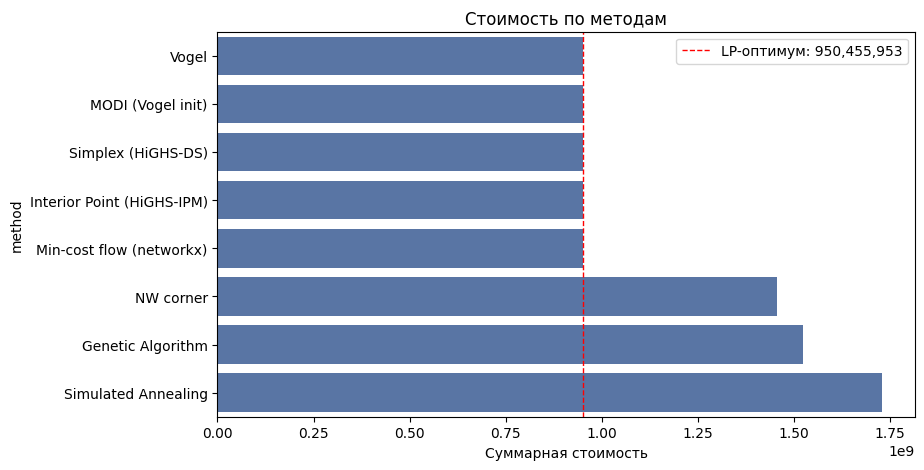

In [ ]:
fig = plt.figure(figsize=(9, 5))
df = pd.DataFrame([{"method": name, "cost": r.cost} for name, r in results.items()]).sort_values("cost")
sns.barplot(data=df, x="cost", y="method", color="#4C72B0")
plt.axvline(lp_cost, color="red", linestyle="--", linewidth=1, label=f"LP-оптимум: {lp_cost:,.0f}")
plt.xlabel("Суммарная стоимость")
plt.title("Стоимость по методам")
plt.legend()
plt.show()

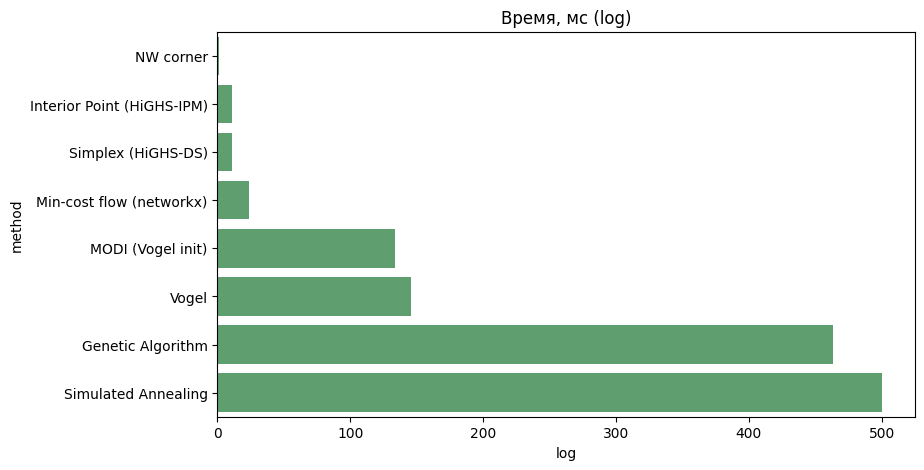

In [ ]:
fig = plt.figure(figsize=(9, 5))
df = pd.DataFrame([{"method": name, "time_ms": r.wall_time_s * 1000} for name, r in results.items()]).sort_values("time_ms")
sns.barplot(data=df, x="time_ms", y="method", color="#55A868")
plt.xlabel("log")
plt.title("Время, мс (log)")
plt.show()

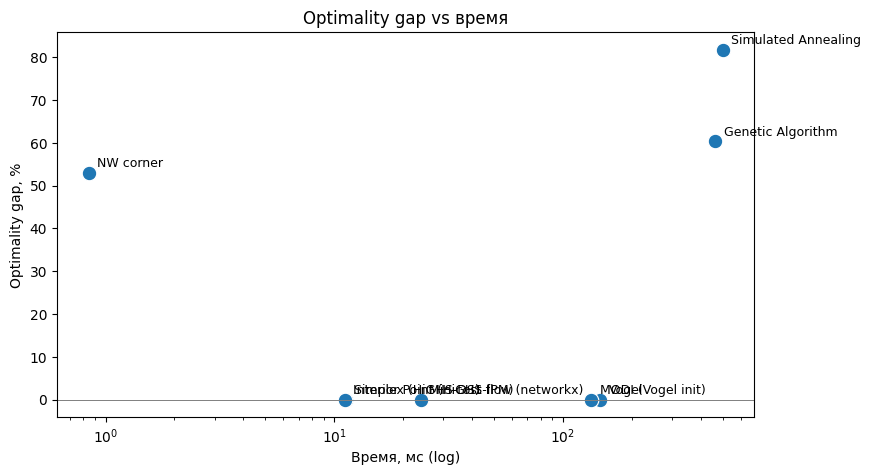

In [ ]:
_, ax = plt.subplots(figsize=(9, 5))
rows = []
for name, r in results.items():
    rows.append({
        "method": name,
        "time_ms": r.wall_time_s * 1000,
        "gap_pct": (r.cost - lp_cost) / lp_cost * 100,
    })
df = pd.DataFrame(rows)

sns.scatterplot(data=df, x="time_ms", y="gap_pct", s=110)
for _, row in df.iterrows():
        ax.annotate(row["method"], (row["time_ms"], row["gap_pct"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Время, мс (log)")
ax.set_ylabel("Optimality gap, %")
ax.set_title("Optimality gap vs время")
ax.axhline(0, color="grey", linewidth=0.7);

## 6. Полная задача 4 × 25 000

На полном датасете 100 тыс. переменных метаэвристики бессмысленны, прогоняем симплекс, метод внутренней точки и min-cost flow

In [ ]:
big_results = {}
for name in ['Simplex (HiGHS-DS)', 'Interior Point (HiGHS-IPM)', 'Min-cost flow (networkx)']:
    print(f'{name}', flush=True)
    res = SOLVER_REGISTRY[name](problem_full)
    big_results[name] = res
    print(f'cost={res.cost:,.0f}, time={res.wall_time_s:.2f} s, iters={res.iterations}')

lp_full = big_results['Simplex (HiGHS-DS)'].cost
pd.DataFrame([
    {'method': k,
     'cost': r.cost,
     'gap_%': optimality_gap(r.cost, lp_full),
     'time_s': r.wall_time_s}
    for k, r in big_results.items()
]).round(4).set_index('method')

Simplex (HiGHS-DS)
cost=119,519,984,065, time=3.54 s, iters=25000
Interior Point (HiGHS-IPM)
cost=119,519,984,065, time=2.60 s, iters=32
Min-cost flow (networkx)
cost=119,519,984,065, time=10.84 s, iters=None


,cost,gap_%,time_s
method,,,
Simplex (HiGHS-DS),1.195200e+11,0.0,3.5421
Interior Point (HiGHS-IPM),1.195200e+11,-0.0,2.5975
Min-cost flow (networkx),1.195200e+11,-0.0,10.8440


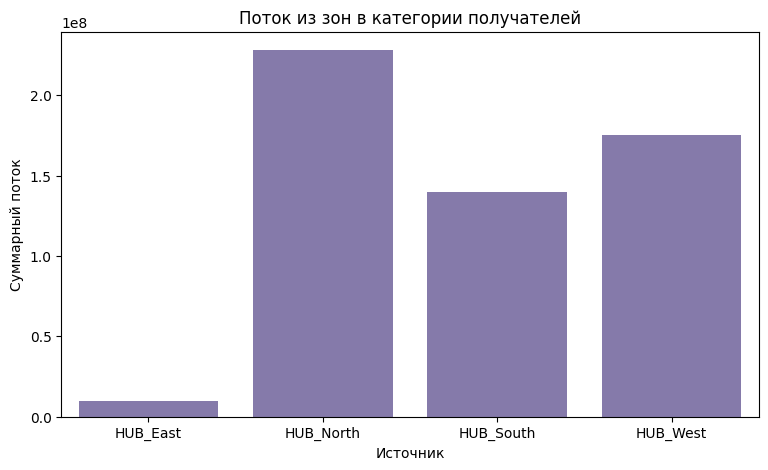

In [ ]:
fig = plt.figure(figsize=(9, 5))
flow = big_results['Simplex (HiGHS-DS)'].x.sum(axis=1)
df = pd.DataFrame({"source": problem_full.sources, "flow": flow})
sns.barplot(data=df, x="source", y="flow", color="#8172B2")
plt.xlabel("Источник")
plt.ylabel("Суммарный поток")
plt.title("Поток из зон в категории получателей")
plt.show()